## Анализ медицинских страховых данных

Цель: Провести EDA, выявить закономерности и сформировать бизнес-выводы на основе набора медицинских страховых данных.

Источник данных: `insurance_small.csv`

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import process
import pandas as pd
from scipy import stats
from scipy.stats import median_abs_deviation


%matplotlib inline
sns.set(style="whitegrid")

In [71]:
df = pd.read_csv('insurance_small.csv')
df.head()

,Unnamed: 0,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,zero,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


Уберем пропуски
Переведем текстовые значения в численные в `children` ('zero' -> 0)
Устраним опечатки в `region` ('northvest' -> 'northwest') 
Проверим возраст 

In [72]:
df.isnull().sum()

text_to_number = {
    'zero': 0,
    'one': 1,
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six':6,
    'seven':7,
    'eight':8,
    'nine':9,
    'ten':10
}
df['children'] = df['children'].astype(str).str.lower().map(text_to_number).fillna(df['children'])
df['children'] = pd.to_numeric(df['children'], errors='coerce')
#print(df['children'].unique())

#print(df['region'].unique())
normal_regions = ['northeast', 'northwest', 'southeast', 'southwest']

def edit_region(value):
    match, score, _ = process.extractOne(str(value).lower().strip(), normal_regions)
    return match if score > 80 else 'unknown'  

df['region'] = df['region'].apply(edit_region)
#print(df['region'])

df = df[(df['age'] > 0) & (df['age'] < 120)]

Найдем выбросы через boxplot-визуализации для каждого числового признака

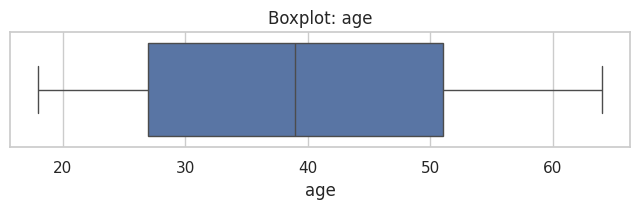

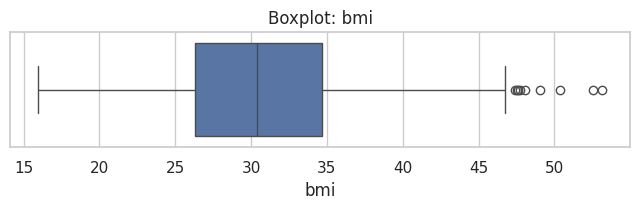

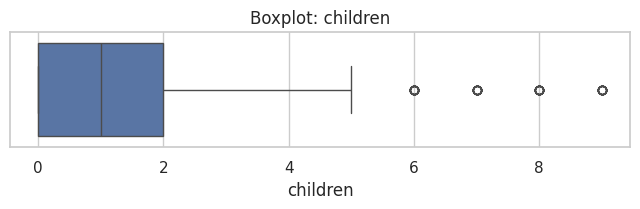

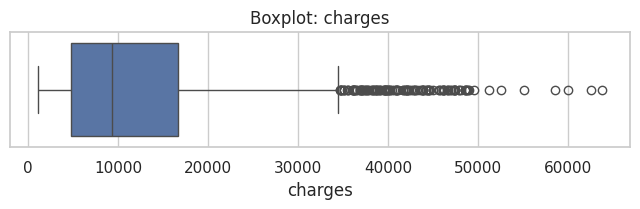

In [73]:
num_features = ['age', 'bmi', 'children', 'charges']

for i in num_features:
    plt.figure(figsize=(8, 1.5))
    sns.boxplot(x=i, data=df)
    plt.title(f'Boxplot: {i}')
    plt.show()

Выявление экстренной помощи (“emergency_care”)
Логика: если charges > 3 стандартных отклонений от среднего значения → emergency_care = 1

In [74]:
charges_z = np.abs(stats.zscore(df['charges']))
df['emergency_care'] = (charges_z > 3).astype(int)
df['emergency_care'].value_counts()

#print(df['charges'].sum())
#print(df[df['emergency_care'] == 1]['charges'].sum())

emergency_care
0    1331
1       7
Name: count, dtype: int64

Корреляции между числовыми признаками

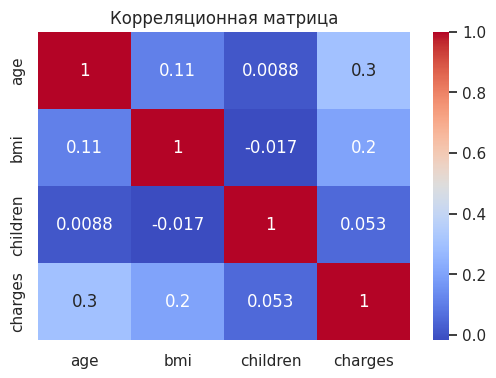

In [75]:
corr_matrix = df[num_features].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

Взаимосвязи с категориальными признаками

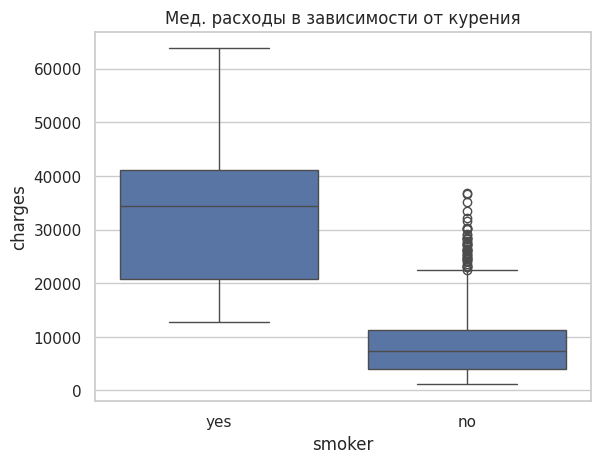

In [76]:
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Мед. расходы в зависимости от курения')
plt.show()

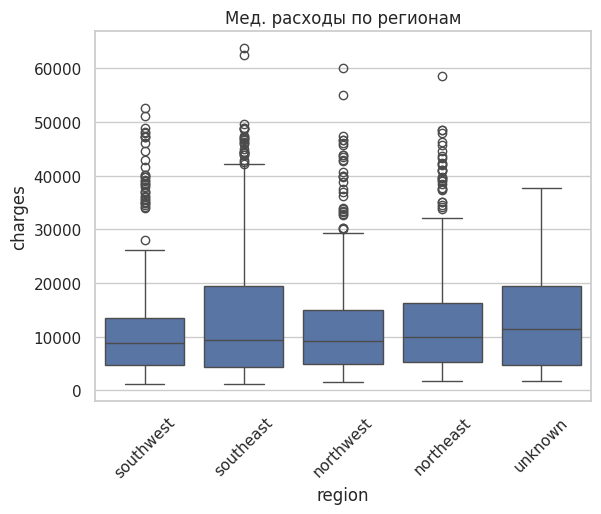

In [77]:
sns.boxplot(data=df, x='region', y='charges')
plt.xticks(rotation=45)
plt.title('Мед. расходы по регионам')
plt.show()

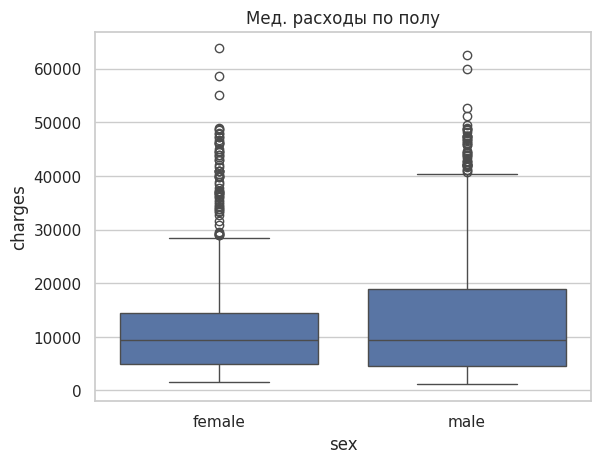

In [78]:
sns.boxplot(data=df, x='sex', y='charges')
plt.title('Мед. расходы по полу')
plt.show()

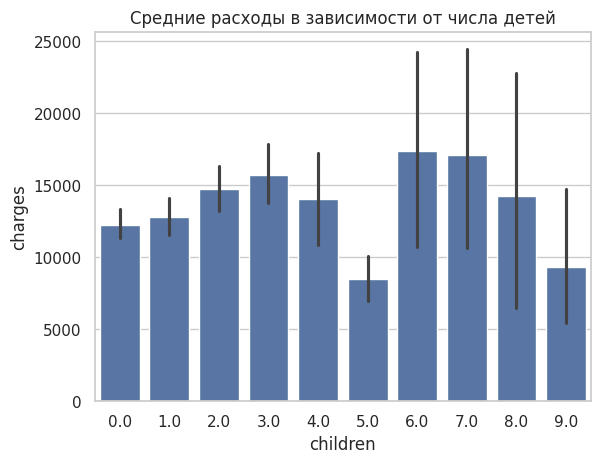

In [79]:
sns.barplot(data=df, x='children', y='charges')
plt.title('Средние расходы в зависимости от числа детей')
plt.show()

Выявление аномалии региона (“regional_outlier”)
Логика: если charges значительно отличаются от медианных значений по региону → regional_outlier
= 1

In [80]:
region_med = df.groupby('region')['charges'].median().to_dict()
region_mad = df.groupby('region')['charges'].apply(median_abs_deviation).to_dict()

def is_regional_outlier(row):
    median = region_med[row['region']]
    mad = region_mad[row['region']]
    return int(abs(row['charges'] - median) > 1.5 * mad)

df['regional_outlier'] = df.apply(is_regional_outlier, axis=1)
df['regional_outlier'].value_counts()


regional_outlier
0    940
1    398
Name: count, dtype: int64

Выявление рискованного поведения для здоровья (“health_risk_behavior”)
Логика: если BMI > 30 И smoker = yes И charges ниже медианных → health_risk_behavior = 1

In [81]:
median_charges = df['charges'].median()
df['health_risk_behavior'] = (
    (df['bmi'] > 30) &
    (df['smoker'].str.lower() == 'yes') &
    (df['charges'] < median_charges)
).astype(int)

df['health_risk_behavior'].value_counts()

health_risk_behavior
0    1338
Name: count, dtype: int64

## Кластеризация клиентов по типам поведения и рискам:
    
- #### Здоровые (не курят, BMI в норме, низкие расходы)  
Подход: скидки, долгосрочные тарифы
- #### В зоне риска (курят, BMI повышен, низкие текущие расходы)  
Подход: ранняя консультация
- #### Возрастной риск (возраст > 55, высокие расходы)  
Подход: учитывать возрастные особенности 
- #### Экстренная помощь (`emergency_care == 1`)  
Подход: мониторинг
- #### Региональные аномалии (`regional_outlier == 1`)  
Подход: изучить особенности региона для улучшения тарифов, предложений

# Ключевые выводы

- **Курение — главный драйвер расходов.** Курящие составляют 20% клиентов, но дают 49% всех расходов; их медианные расходы в 4,7 раза выше (34,5 тыс. против 7,3 тыс.)
- **Курение + ожирение (BMI > 30)** — самая дорогая группа: медиана 40,9 тыс., в 6 раз выше, чем у некурящих с BMI ≤ 30. Это ключевой сегмент для тарификации и профилактики
- **Возраст** повышает расходы плавно: у клиентов 55+ медиана 13,4 тыс. против 7,7 тыс. у остальных
- **Экстренные случаи** (`emergency_care`, z-score > 3) редки: 7 клиентов и 2,3% расходов, поэтому основную нагрузку формируют не они, а устойчивые факторы риска. При этом топ-10% клиентов дают 32% всех расходов
- **Скрытых рисков** (`health_risk_behavior`) не найдено: у курящих с ожирением расходы уже высокие, риск быстро материализуется, поэтому нужна ранняя профилактика
- **Регионы** отличаются умеренно (медианы 8,7–10,0 тыс.). 47 записей с нераспознанным регионом (`unknown`) стоит разобрать отдельно
- Предложенные сегменты можно использовать для кастомизации тарифов и программ профилактики